# Minimal WES vs in situ CNV Notebook

This notebook is a compact workflow for:

1. selecting one WES CSV and one sample-specific in situ CSV
2. choosing one `sample_name`
3. plotting either raw or binned WES vs in situ values
4. selecting thresholds on the chosen input resolution
5. exporting the final metrics to `.csv`

Assumption for the in situ file:
- the CSV is already sample specific
- the CNV values are stored in the column `CNV_value`

`bin_size_bp = None` switches the workflow to raw gene-level mode.


## Inputs

Edit only these five values, then run the notebook from top to bottom.

The in situ CSV is expected to contain these columns:
- `gene`
- `chromosome`
- `start`
- `end`
- `CNV_value`


In [1]:
from pathlib import Path

wes_file = Path('/home/augusta/storage3/augusta/insituCNV/data_from_Kang/sample_selection/WES_PureCN/WES_PureCN_output.csv')
insitu_file = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Validation/insitucnv_CNV_outputs/1105_BL_tumor_mean_cnv_per_gene_smooth.csv')

sample_name = '1105_BL'
bin_size_bp = 20_000_000  # set to None for raw gene-level mode
min_genes_per_bin = 5


In [2]:
import pandas as pd
pd.read_csv(insitu_file)

,gene,chromosome,start,end,CNV_value
0,A2ML1,chr12,8822621,8887001,-0.177268
1,AAMP,chr2,218264123,218270257,0.070584
2,AAR2,chr20,36236459,36270918,-0.001411
3,AARSD1,chr17,42950526,42964498,0.006642
4,ABAT,chr16,8674596,8784575,0.006061
...,...,...,...,...,...
5083,ZSCAN26,chr6,28267010,28278224,0.000915
5084,ZSWIM6,chr5,61332258,61546172,0.000129
5085,ZUP1,chr6,116635618,116668794,0.019771
5086,ZYG11B,chr1,52726453,52827336,0.043369


## Helpers

These functions handle sample resolution, data loading, binning, plotting, threshold search, and export.


In [3]:
import csv
import re
from pathlib import Path
from statistics import mean

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

NOTEBOOK_DIR = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics')
output_dir = NOTEBOOK_DIR / 'results'
output_dir.mkdir(parents=True, exist_ok=True)


def slugify(text):
    """Return a filesystem-safe label for filenames."""
    return re.sub(r'[^A-Za-z0-9._-]+', '_', str(text)).strip('_')


def output_path(stem, suffix):
    """Build an output path using only the sample name and the output description."""
    prefix = slugify(sample_name).replace('_', '')
    return output_dir / f"{prefix}__{slugify(stem)}{suffix}"


def save_current_figure(stem):
    """Save the current matplotlib figure as PDF."""
    plt.gcf().savefig(output_path(stem, '.pdf'), format='pdf', bbox_inches='tight')


def save_dataframe(df, stem, index=False):
    """Save a pandas DataFrame as CSV."""
    df.to_csv(output_path(stem, '.csv'), index=index)


def chr_to_num(chrom):
    """Convert chromosome labels like 'chr1' or 'X' into sortable integers."""
    c = str(chrom).strip().replace('chr', '').replace('CHR', '')
    if c in ('X', 'x'):
        return 23
    if c in ('Y', 'y'):
        return 24
    try:
        n = int(c)
        if 1 <= n <= 24:
            return n
    except ValueError:
        pass
    return None


def resolve_wes_sample_id(sample_name, wes_path):
    """Resolve one user-facing sample name into a WES sampleID.

    Accepted examples:
    - '1105_BL'
    - 'UE-2971-1105-0'

    The in situ file is assumed to be sample specific, so no in situ column lookup is needed.
    """
    with wes_path.open(newline='') as f:
        wes_reader = csv.DictReader(f)
        wes_ids = sorted({row['sampleID'] for row in wes_reader})

    if sample_name in wes_ids:
        return sample_name

    patient_state = str(sample_name)
    if '_' in patient_state:
        patient, state = patient_state.split('_', 1)
        state_map = {'BL': '0', 'K2': '2', 'V2': '2', 'OP': 'OP'}
        mapped_state = state_map.get(state)
        if mapped_state is not None:
            candidate = f'UE-2971-{patient}-{mapped_state}'
            if candidate in wes_ids:
                return candidate

    raise ValueError(
        f"Could not resolve sample_name={sample_name!r} to a WES sampleID. "
        f"Example WES IDs: {wes_ids[:6]}"
    )


def load_wes_segments(path, sample_id):
    """Load WES segments for one sample."""
    rows = []
    with path.open(newline='') as f:
        reader = csv.DictReader(f)
        for r in reader:
            if r['sampleID'] != sample_id:
                continue
            chr_num = chr_to_num(r['chrom'])
            if chr_num is None:
                continue
            try:
                start = int(float(r['loc.start']))
                end = int(float(r['loc.end']))
                seg_mean = float(r['seg.mean'])
                c_val = float(r['C'])
            except (TypeError, ValueError):
                continue
            if end < start:
                start, end = end, start
            rows.append({
                'chrom': str(r['chrom']),
                'chr_num': chr_num,
                'start': start,
                'end': end,
                'seg_mean': seg_mean,
                'C': c_val,
            })
    rows.sort(key=lambda x: (x['chr_num'], x['start']))
    return rows


def load_insitu_gene_values(path, value_col='CNV_value'):
    """Load gene-level in situ CNV values from a sample-specific file.

    The input file must already represent a single sample and contain a fixed
    CNV value column, by default `CNV_value`.
    """
    rows = []
    with path.open(newline='') as f:
        first = f.readline()
        f.seek(0)
        delim = '	' if ('	' in first and first.count('	') > first.count(',')) else ','
        reader = csv.DictReader(f, delimiter=delim)
        required = {'gene', 'chromosome', 'start', 'end', value_col}
        missing = required.difference(reader.fieldnames or [])
        if missing:
            raise ValueError(f'Missing in situ columns: {sorted(missing)}')

        for r in reader:
            chr_num = chr_to_num(r['chromosome'])
            if chr_num is None:
                continue
            try:
                start = int(float(r['start']))
                end = int(float(r['end']))
                value = float(r[value_col])
            except (TypeError, ValueError, KeyError):
                continue
            if end < start:
                start, end = end, start
            rows.append({
                'gene': r['gene'],
                'chrom': str(r['chromosome']),
                'chr_num': chr_num,
                'start': start,
                'end': end,
                'mid': 0.5 * (start + end),
                'value': value,
            })
    rows.sort(key=lambda x: (x['chr_num'], x['mid']))
    return rows


def build_genome_axis(*series_list):
    """Create one concatenated genome axis shared by WES and in situ rows."""
    chr_max_end = {}
    for series in series_list:
        for r in series:
            chr_max_end[r['chr_num']] = max(chr_max_end.get(r['chr_num'], 0), r['end'])

    chromosomes = sorted(chr_max_end)
    offsets = {}
    running = 0
    for c in chromosomes:
        offsets[c] = running
        running += chr_max_end[c]

    def genome_x(chr_num, pos):
        return offsets[chr_num] + pos

    chr_midpoints = []
    for c in chromosomes:
        label = str(c) if c < 23 else ('X' if c == 23 else 'Y')
        chr_midpoints.append((offsets[c] + chr_max_end[c] / 2.0, label))

    return chr_max_end, chromosomes, offsets, running, genome_x, chr_midpoints


def overlap_len(a0, a1, b0, b1):
    """Return the inclusive overlap length between two genomic intervals."""
    left = max(a0, b0)
    right = min(a1, b1)
    return max(0, right - left + 1)


def wes_weighted_segmean_for_interval(segs, start, end):
    """Average WES seg.mean over an interval using overlap length as the weight."""
    weighted_sum = 0.0
    total = 0
    for s in segs:
        ov = overlap_len(start, end, s['start'], s['end'])
        if ov > 0:
            weighted_sum += s['seg_mean'] * ov
            total += ov
    if total == 0:
        return None
    return weighted_sum / total


def build_metric_rows(wes, insitu, bin_size_bp=None, min_genes_per_bin=5):
    """Build the comparison rows used both for plotting and for threshold selection.

    If `bin_size_bp` is None, each in situ gene acts as one comparison row.
    Otherwise the genome is split into fixed-width bins.
    """
    wes_by_chr = {}
    for r in wes:
        wes_by_chr.setdefault(r['chr_num'], []).append(r)

    insitu_by_chr = {}
    for r in insitu:
        insitu_by_chr.setdefault(r['chr_num'], []).append(r)

    chr_max_end, chromosomes, offsets, running, genome_x, chr_midpoints = build_genome_axis(wes, insitu)
    rows = []

    if bin_size_bp is None:
        for gene in insitu:
            wes_val = wes_weighted_segmean_for_interval(
                wes_by_chr.get(gene['chr_num'], []),
                int(gene['start']),
                int(gene['end']),
            )
            if wes_val is None:
                continue
            rows.append({
                'mode': 'raw',
                'chr_num': gene['chr_num'],
                'start': gene['start'],
                'end': gene['end'],
                'x': genome_x(gene['chr_num'], gene['mid']),
                'wes_segmean': wes_val,
                'insitu_value': gene['value'],
                'n_genes': 1,
                'gene': gene['gene'],
            })
    else:
        for c in chromosomes:
            chr_len = chr_max_end[c]
            start = 1
            while start <= chr_len:
                end = min(start + bin_size_bp - 1, chr_len)
                wes_val = wes_weighted_segmean_for_interval(wes_by_chr.get(c, []), start, end)
                ins_vals = [g['value'] for g in insitu_by_chr.get(c, []) if start <= g['mid'] <= end]
                if wes_val is not None and len(ins_vals) >= min_genes_per_bin:
                    rows.append({
                        'mode': 'binned',
                        'chr_num': c,
                        'start': start,
                        'end': end,
                        'x': genome_x(c, 0.5 * (start + end)),
                        'wes_segmean': wes_val,
                        'insitu_value': mean(ins_vals),
                        'n_genes': len(ins_vals),
                    })
                start = end + 1

    return rows, chr_max_end, chromosomes, offsets, running, genome_x, chr_midpoints


def plot_comparison(wes, insitu, metric_rows, chromosomes, offsets, chr_midpoints, bin_size_bp, min_genes_per_bin):
    """Plot WES and in situ CNV tracks in stacked panels with filled gain/loss areas."""
    fig, axes = plt.subplots(2, 1, figsize=(18, 7), sharex=True, constrained_layout=True)

    if bin_size_bp is None:
        x_w = np.array([0.5 * (r['x0'] + r['x1']) for r in wes], dtype=float)
        y_w = np.array([r['seg_mean'] for r in wes], dtype=float)
        x_i = np.array([r['x'] for r in insitu], dtype=float)
        y_i = np.array([r['value'] for r in insitu], dtype=float)
        title = 'Raw WES vs in situ comparison'
    else:
        x_w = np.array([r['x'] for r in metric_rows], dtype=float)
        y_w = np.array([r['wes_segmean'] for r in metric_rows], dtype=float)
        x_i = np.array([r['x'] for r in metric_rows], dtype=float)
        y_i = np.array([r['insitu_value'] for r in metric_rows], dtype=float)
        title = f'Binned WES vs in situ comparison (bin_size={bin_size_bp:,}, min_genes={min_genes_per_bin})'

    series_specs = [
        (axes[0], x_w, y_w, 'WES seg.mean'),
        (axes[1], x_i, y_i, 'in situ value' if bin_size_bp is None else 'in situ mean'),
    ]

    for ax, x, y, panel_title in series_specs:
        ax.fill_between(x, 0, y, where=(y >= 0), color='firebrick', alpha=0.35, interpolate=True)
        ax.fill_between(x, 0, y, where=(y <= 0), color='royalblue', alpha=0.35, interpolate=True)
        ax.plot(x, y, color='black', linewidth=1.2, alpha=0.9)
        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        for c in chromosomes:
            ax.axvline(offsets[c], color='lightgray', linewidth=0.5)
        ax.set_ylabel('CNV signal')
        ax.set_title(panel_title)

    axes[-1].set_xticks([m for m, _ in chr_midpoints])
    axes[-1].set_xticklabels([lab for _, lab in chr_midpoints])
    axes[-1].set_xlabel('Chromosome')
    fig.suptitle(title, fontsize=14)
    save_current_figure('comparison_plot')
    plt.show()


def safe_auc(y_true, y_score):
    """Compute ROC AUC safely for one-vs-rest labels."""
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        return float('nan')
    return float(roc_auc_score(y_true, y_score))


def safe_div(a, b):
    """Return a / b, or 0.0 when the denominator is zero."""
    return float(a) / float(b) if b else 0.0


def classify_symmetric(values, threshold):
    """Classify values into loss/neutral/gain using symmetric thresholds around zero."""
    values = np.asarray(values, dtype=float)
    out = np.zeros(len(values), dtype=int)
    out[values >= threshold] = 1
    out[values <= -threshold] = -1
    return out


def select_thresholds(metric_df):
    """Select thresholds using the current two-stage notebook rule.

    Stage 1:
    - choose `wes_thr` by maximizing mean AUC across gain and loss

    Stage 2:
    - choose `insitu_thr` by maximizing mean F1 across gain and loss
      conditional on the selected WES threshold
    """
    wes_values = metric_df['wes_segmean'].to_numpy(dtype=float)
    insitu_values = metric_df['insitu_value'].to_numpy(dtype=float)

    wes_candidates = np.sort(metric_df['wes_segmean'].abs().round(6).unique())
    insitu_candidates = np.sort(metric_df['insitu_value'].abs().round(6).unique())

    wes_candidates = wes_candidates[(wes_candidates >= 0.005) & (wes_candidates <= min(0.20, wes_candidates.max()))]
    insitu_candidates = insitu_candidates[(insitu_candidates >= 0.0001) & (insitu_candidates <= min(0.20, insitu_candidates.max()))]

    if len(wes_candidates) == 0:
        wes_candidates = np.sort(metric_df['wes_segmean'].abs().unique())
    if len(insitu_candidates) == 0:
        insitu_candidates = np.sort(metric_df['insitu_value'].abs().unique())

    wes_rows = []
    for thr in wes_candidates:
        truth = classify_symmetric(wes_values, float(thr))
        n_gain = int(np.sum(truth == 1))
        n_loss = int(np.sum(truth == -1))
        if n_gain < 5 or n_loss < 5:
            continue
        auc_gain = safe_auc((truth == 1).astype(int), insitu_values)
        auc_loss = safe_auc((truth == -1).astype(int), -insitu_values)
        auc_mean = float(np.nanmean([auc_gain, auc_loss]))
        wes_rows.append({
            'wes_threshold': float(thr),
            'auc_gain': auc_gain,
            'auc_loss': auc_loss,
            'auc_mean': auc_mean,
            'n_truth_gain': n_gain,
            'n_truth_loss': n_loss,
        })

    wes_grid = pd.DataFrame(wes_rows).sort_values(['auc_mean', 'auc_gain', 'auc_loss'], ascending=False).reset_index(drop=True)
    if wes_grid.empty:
        raise ValueError('No valid WES thresholds found after AUC filtering.')

    wes_thr = float(wes_grid.iloc[0]['wes_threshold'])
    truth = classify_symmetric(wes_values, wes_thr)

    insitu_rows = []
    for thr in insitu_candidates:
        pred = classify_symmetric(insitu_values, float(thr))
        tp_gain = np.sum((truth == 1) & (pred == 1))
        fp_gain = np.sum((truth != 1) & (pred == 1))
        fn_gain = np.sum((truth == 1) & (pred != 1))
        tp_loss = np.sum((truth == -1) & (pred == -1))
        fp_loss = np.sum((truth != -1) & (pred == -1))
        fn_loss = np.sum((truth == -1) & (pred != -1))
        f1_gain = 0.0 if (2 * tp_gain + fp_gain + fn_gain) == 0 else (2 * tp_gain) / (2 * tp_gain + fp_gain + fn_gain)
        f1_loss = 0.0 if (2 * tp_loss + fp_loss + fn_loss) == 0 else (2 * tp_loss) / (2 * tp_loss + fp_loss + fn_loss)
        insitu_rows.append({
            'insitu_threshold': float(thr),
            'f1_gain': float(f1_gain),
            'f1_loss': float(f1_loss),
            'f1_mean': float(np.mean([f1_gain, f1_loss])),
            'accuracy_3class': float(np.mean(pred == truth)),
        })

    insitu_grid = pd.DataFrame(insitu_rows).sort_values(['f1_mean', 'f1_gain', 'f1_loss', 'accuracy_3class'], ascending=False).reset_index(drop=True)
    insitu_thr = float(insitu_grid.iloc[0]['insitu_threshold'])

    return wes_thr, insitu_thr, wes_grid, insitu_grid


def compute_metrics(metric_df, wes_thr, insitu_thr):
    """Compute summary AUC, precision, recall, and F1 values at the selected thresholds."""
    wes_values = metric_df['wes_segmean'].to_numpy(dtype=float)
    insitu_values = metric_df['insitu_value'].to_numpy(dtype=float)
    truth = classify_symmetric(wes_values, wes_thr)
    pred = classify_symmetric(insitu_values, insitu_thr)

    def precision_for(cls):
        tp = np.sum((truth == cls) & (pred == cls))
        fp = np.sum((truth != cls) & (pred == cls))
        return safe_div(tp, tp + fp)

    def recall_for(cls):
        tp = np.sum((truth == cls) & (pred == cls))
        fn = np.sum((truth == cls) & (pred != cls))
        return safe_div(tp, tp + fn)

    def f1_for(cls):
        p = precision_for(cls)
        r = recall_for(cls)
        return safe_div(2 * p * r, p + r)

    auc_gain = safe_auc((truth == 1).astype(int), insitu_values)
    auc_loss = safe_auc((truth == -1).astype(int), -insitu_values)

    metrics = pd.DataFrame([{
        'sample_name': sample_name,
        'wes_sample_id': wes_sample_id,
        'insitu_file': insitu_file.name,
        'mode': 'raw' if bin_size_bp is None else 'binned',
        'bin_size_bp': bin_size_bp,
        'min_genes_per_bin': min_genes_per_bin,
        'n_rows': int(len(metric_df)),
        'wes_threshold': float(wes_thr),
        'insitu_threshold': float(insitu_thr),
        'auc_gain': auc_gain,
        'auc_loss': auc_loss,
        'auc_mean': float(np.nanmean([auc_gain, auc_loss])),
        'precision_gain': precision_for(1),
        'precision_loss': precision_for(-1),
        'precision_mean': float(np.mean([precision_for(1), precision_for(-1)])),
        'recall_gain': recall_for(1),
        'recall_loss': recall_for(-1),
        'recall_mean': float(np.mean([recall_for(1), recall_for(-1)])),
        'f1_gain': f1_for(1),
        'f1_loss': f1_for(-1),
        'f1_mean': float(np.mean([f1_for(1), f1_for(-1)])),
    }])
    return metrics, truth, pred


def plot_threshold_scatter(metric_df, truth_labels, wes_thr, insitu_thr):
    """Plot WES vs in situ values with the selected thresholds overlaid."""
    fig, ax = plt.subplots(1, 1, figsize=(6.5, 5.5), constrained_layout=True)
    colors = {1: 'tab:red', 0: 'gray', -1: 'tab:blue'}
    labels = {1: 'truth=gain', 0: 'truth=neutral', -1: 'truth=loss'}

    for cls in [1, 0, -1]:
        mask = truth_labels == cls
        if np.any(mask):
            ax.scatter(
                metric_df.loc[mask, 'wes_segmean'],
                metric_df.loc[mask, 'insitu_value'],
                s=20,
                alpha=0.70,
                c=colors[cls],
                label=labels[cls],
            )

    ax.axvline(wes_thr, color='black', linestyle='--', linewidth=0.9)
    ax.axvline(-wes_thr, color='black', linestyle='--', linewidth=0.9)
    ax.axhline(insitu_thr, color='darkorange', linestyle='--', linewidth=0.9)
    ax.axhline(-insitu_thr, color='darkorange', linestyle='--', linewidth=0.9)
    ax.set_xlabel('WES seg.mean')
    ax.set_ylabel('in situ value')
    ax.set_title('Threshold scatter plot')
    ax.legend(loc='best', fontsize=8)
    save_current_figure('threshold_scatter')
    plt.show()


def build_confusion_tables(truth_labels, pred_labels):
    """Return confusion matrices as count and row-percentage DataFrames."""
    label_order = [-1, 0, 1]
    label_name = {-1: 'loss', 0: 'neutral', 1: 'gain'}

    cm = pd.crosstab(pd.Series(truth_labels, name='truth'), pd.Series(pred_labels, name='pred'))
    cm = cm.reindex(index=label_order, columns=label_order, fill_value=0)
    cm.index = [label_name[i] for i in cm.index]
    cm.columns = [label_name[i] for i in cm.columns]
    cm_pct = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0) * 100.0
    return cm, cm_pct
from matplotlib.colors import LinearSegmentedColormap

white_yellow_cmap = LinearSegmentedColormap.from_list(
    "white_yellow",
    ["#ffffff", "#e3c65c"]
)

def plot_confusion_matrix(truth_labels, pred_labels):
    """Plot a mild green confusion matrix annotated with counts and row percentages.
       Rows = Predicted, Columns = Truth.
    """
    cm, cm_pct = build_confusion_tables(truth_labels, pred_labels)

    # Transpose so rows = predicted, columns = truth
    cm = cm.T
    cm_pct = cm_pct.T

    fig, ax = plt.subplots(1, 1, figsize=(5.8, 4.8), constrained_layout=True)
    im = ax.imshow(cm_pct.to_numpy(), cmap=white_yellow_cmap, vmin=0, vmax=100)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                f"{int(cm.iloc[i, j])}\n{cm_pct.iloc[i, j]:.1f}%",
                ha='center',
                va='center',
                color='black',
                fontsize=9,
            )

    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.set_xticklabels(cm.columns)  # Truth
    ax.set_yticklabels(cm.index)    # Predicted
    ax.set_xlabel('Truth')
    ax.set_ylabel('Predicted')
    ax.set_title('Confusion matrix (count and row %)')

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    save_current_figure('confusion_matrix_green')
    plt.show()
    return cm, cm_pct


def plot_truth_overlay(metric_df, chromosomes, offsets, chr_midpoints, genome_x):
    """Plot WES vs in situ values and shade bins that are true gains or losses."""
    fig, ax = plt.subplots(1, 1, figsize=(18, 4.5), constrained_layout=True)

    for _, r in metric_df.iterrows():
        x0 = genome_x(int(r['chr_num']), float(r['start']))
        x1 = genome_x(int(r['chr_num']), float(r['end']))
        if r['truth'] == 1:
            ax.axvspan(x0, x1, color='red', alpha=0.10)
        elif r['truth'] == -1:
            ax.axvspan(x0, x1, color='blue', alpha=0.10)

    bx = metric_df['x'].to_numpy()
    ax.plot(bx, metric_df['wes_segmean'].to_numpy(), color='black', lw=1.8, label='WES seg.mean')
    ax.plot(bx, metric_df['insitu_value'].to_numpy(), color='darkorange', lw=1.4, label='in situ value')
    ax.axhline(0, color='gray', ls='--', lw=0.8)

    for c in chromosomes:
        ax.axvline(offsets[c], color='lightgray', lw=0.5)
    ax.set_xticks([m for m, _ in chr_midpoints])
    ax.set_xticklabels([lab for _, lab in chr_midpoints])
    ax.set_xlabel('Chromosome')
    ax.set_ylabel('CNV signal')
    ax.set_title('Comparison plot with true gain/loss intervals')
    ax.legend(loc='upper right')
    save_current_figure('truth_gain_loss_overlay')
    plt.show()


def plot_comparison_lines(wes, insitu, metric_rows, chromosomes, offsets, chr_midpoints, bin_size_bp, min_genes_per_bin):
    """Plot the original single-panel line comparison for direct visual comparison."""
    fig, ax = plt.subplots(1, 1, figsize=(18, 4.5), constrained_layout=True)

    if bin_size_bp is None:
        for r in wes:
            ax.plot([r['x0'], r['x1']], [r['seg_mean'], r['seg_mean']], color='black', linewidth=1.0, alpha=0.7)
        ax.scatter([r['x'] for r in insitu], [r['value'] for r in insitu], s=8, alpha=0.35, c='darkorange', label='in situ genes')
        ax.set_title('Raw WES vs in situ comparison (line version)')
    else:
        bx = [r['x'] for r in metric_rows]
        bw = [r['wes_segmean'] for r in metric_rows]
        bi = [r['insitu_value'] for r in metric_rows]
        ax.plot(bx, bw, color='black', linewidth=1.8, alpha=0.95, label='WES seg.mean')
        ax.plot(bx, bi, color='darkorange', linewidth=1.4, alpha=0.95, label='in situ mean')
        ax.set_title(f'Binned WES vs in situ comparison (line version, bin_size={bin_size_bp:,}, min_genes={min_genes_per_bin})')

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    for c in chromosomes:
        ax.axvline(offsets[c], color='lightgray', linewidth=0.5)
    ax.set_xticks([m for m, _ in chr_midpoints])
    ax.set_xticklabels([lab for _, lab in chr_midpoints])
    ax.set_xlabel('Chromosome')
    ax.set_ylabel('CNV signal')
    ax.legend(loc='upper right')
    save_current_figure('comparison_plot_line')
    plt.show()


## Load Data


In [4]:
wes_sample_id = resolve_wes_sample_id(sample_name, wes_file)
wes = load_wes_segments(wes_file, wes_sample_id)
insitu = load_insitu_gene_values(insitu_file, value_col='CNV_value')

if not wes:
    raise ValueError(f'No WES rows found for {wes_sample_id}')
if not insitu:
    raise ValueError(f'No in situ rows found in {insitu_file}')

chr_max_end, chromosomes, offsets, running, genome_x, chr_midpoints = build_genome_axis(wes, insitu)
for r in wes:
    r['x0'] = genome_x(r['chr_num'], r['start'])
    r['x1'] = genome_x(r['chr_num'], r['end'])
for r in insitu:
    r['x'] = genome_x(r['chr_num'], r['mid'])

print('Resolved sample mapping')
print('  WES sampleID   :', wes_sample_id)
print('  in situ file   :', insitu_file)
print('  in situ values : CNV_value')
print('  WES segments   :', len(wes))
print('  in situ genes  :', len(insitu))
print('  output_dir     :', output_dir)


Resolved sample mapping
  WES sampleID   : UE-2971-1105-0
  in situ file   : /home/augusta/storage3/augusta/insituCNV/InSituCNV/Validation/insitucnv_CNV_outputs/1105_BL_tumor_mean_cnv_per_gene_smooth.csv
  in situ values : CNV_value
  WES segments   : 244
  in situ genes  : 4798
  output_dir     : /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results


## Build Comparison Rows


In [5]:
metric_rows, chr_max_end, chromosomes, offsets, genome_length, genome_x, chr_midpoints = build_metric_rows(
    wes=wes,
    insitu=insitu,
    bin_size_bp=bin_size_bp,
    min_genes_per_bin=min_genes_per_bin,
)
metric_df = pd.DataFrame(metric_rows)

if metric_df.empty:
    raise ValueError('No comparison rows were created. Try a smaller bin size or fewer min_genes_per_bin.')

display(metric_df.head())
print('Comparison rows:', len(metric_df))


,mode,chr_num,start,end,x,wes_segmean,insitu_value,n_genes
0,binned,1,1,20000000,10000000.5,0.036722,0.001714,63
1,binned,1,20000001,40000000,30000000.5,0.019465,0.007745,82
2,binned,1,40000001,60000000,50000000.5,0.019465,0.048088,45
3,binned,1,60000001,80000000,70000000.5,0.019465,0.002338,21
4,binned,1,80000001,100000000,90000000.5,0.019465,0.000465,21


Comparison rows: 146


## Comparison Plots

The notebook now shows both comparison styles:
- stacked filled-area version
- original single-panel line version


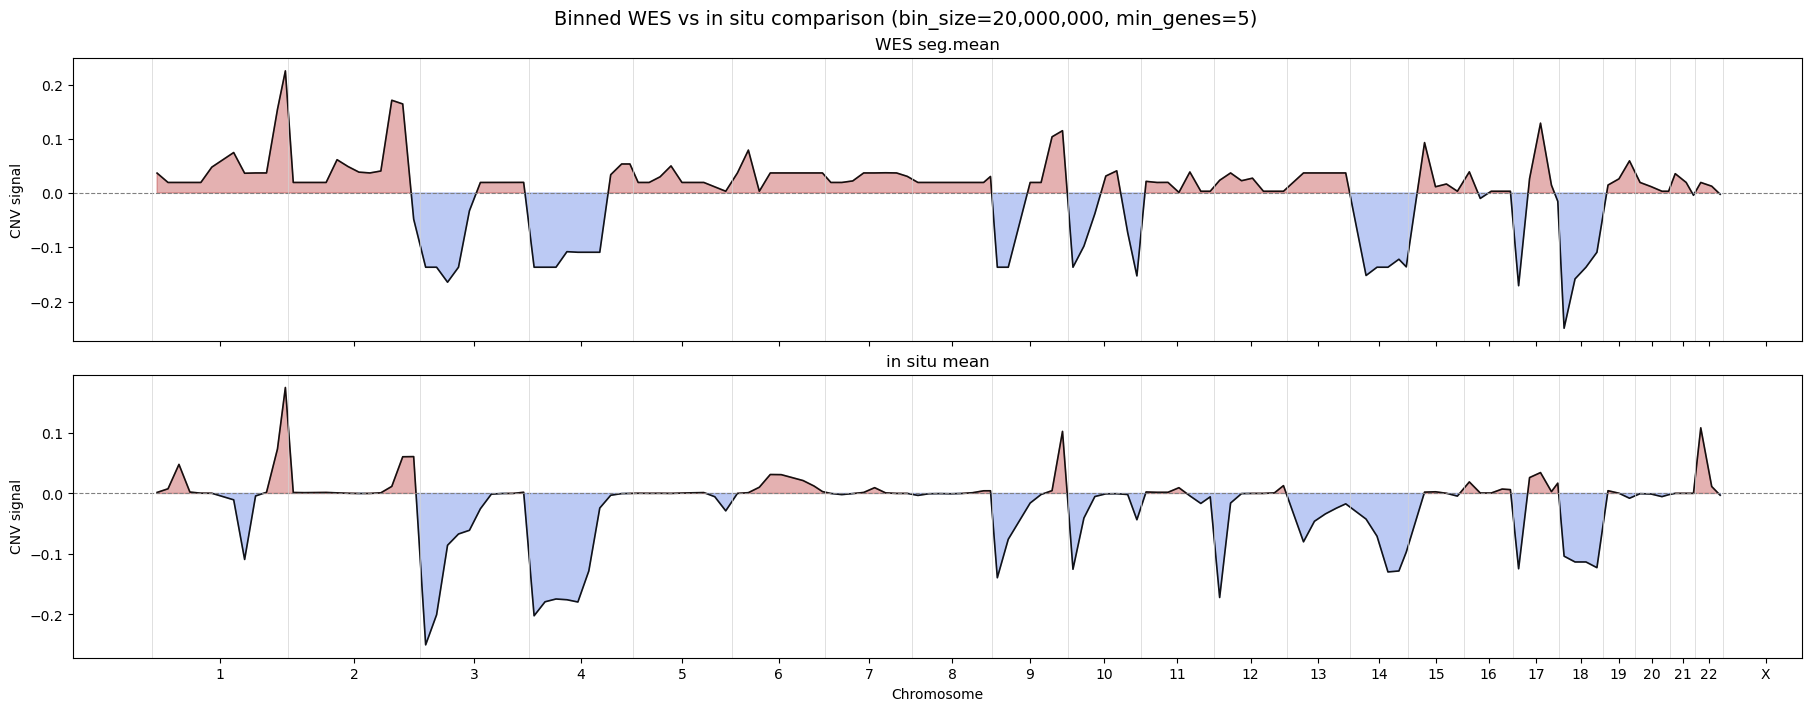

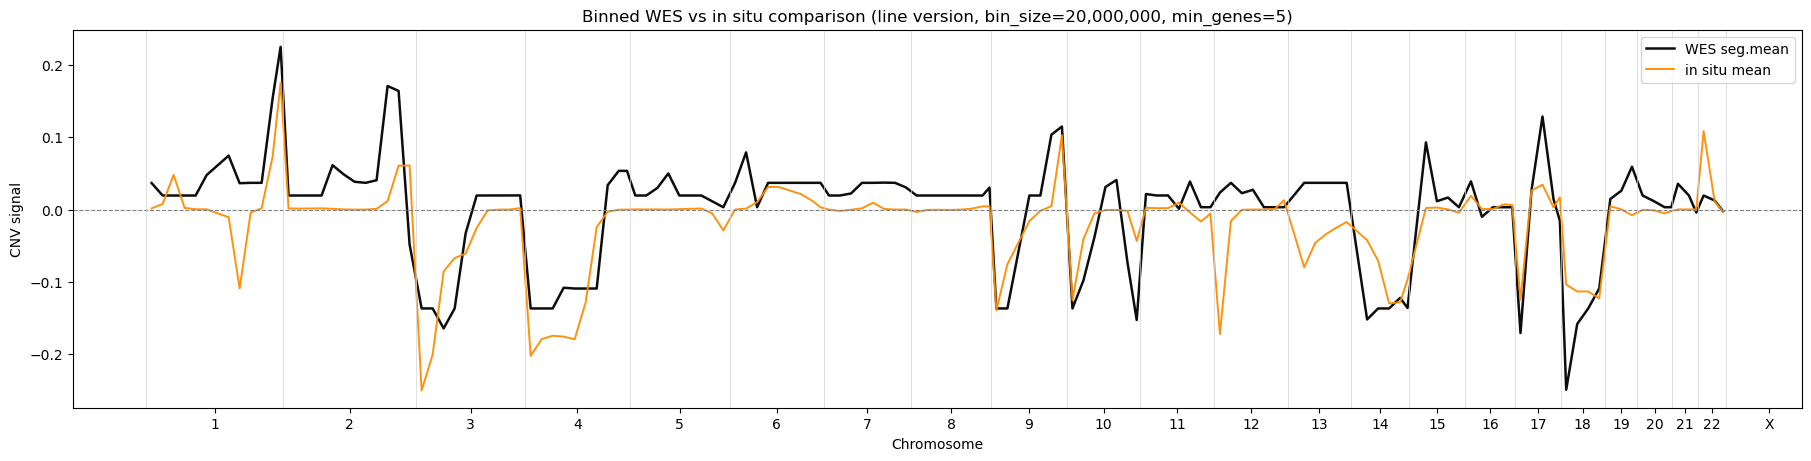

In [6]:
plot_comparison(
    wes=wes,
    insitu=insitu,
    metric_rows=metric_df.to_dict(orient='records'),
    chromosomes=chromosomes,
    offsets=offsets,
    chr_midpoints=chr_midpoints,
    bin_size_bp=bin_size_bp,
    min_genes_per_bin=min_genes_per_bin,
)

plot_comparison_lines(
    wes=wes,
    insitu=insitu,
    metric_rows=metric_df.to_dict(orient='records'),
    chromosomes=chromosomes,
    offsets=offsets,
    chr_midpoints=chr_midpoints,
    bin_size_bp=bin_size_bp,
    min_genes_per_bin=min_genes_per_bin,
)


## Threshold Selection

This follows the current notebook rule:
- choose `wes_thr` by maximizing mean gain/loss AUC
- choose `insitu_thr` by maximizing mean gain/loss F1 conditional on that WES choice


In [7]:
wes_thr, insitu_thr, wes_threshold_grid_df, insitu_threshold_grid_df = select_thresholds(metric_df)

print('Selected thresholds')
print('  WES threshold    :', round(wes_thr, 6))
print('  in situ threshold:', round(insitu_thr, 6))

display(wes_threshold_grid_df.head(10))
display(insitu_threshold_grid_df.head(10))

save_dataframe(wes_threshold_grid_df, 'wes_threshold_auc_grid', index=False)
save_dataframe(insitu_threshold_grid_df, 'insitu_threshold_f1_grid', index=False)


Selected thresholds
  WES threshold    : 0.103615
  in situ threshold: 0.031346


,wes_threshold,auc_gain,auc_loss,auc_mean,n_truth_gain,n_truth_loss
0,0.103615,0.977381,0.985455,0.981418,6,25
1,0.108128,0.977381,0.985455,0.981418,6,25
2,0.109209,0.977381,0.978484,0.977932,6,24
3,0.097953,0.960946,0.984615,0.972780,7,26
4,0.114909,0.977381,0.965476,0.971429,6,20
5,0.122095,0.968794,0.965476,0.967135,5,20
6,0.092958,0.941123,0.984615,0.962869,8,26
7,0.074635,0.916464,0.984615,0.950540,9,26
8,0.079112,0.916464,0.984615,0.950540,9,26
9,0.061415,0.852941,0.976657,0.914799,10,27


,insitu_threshold,f1_gain,f1_loss,f1_mean,accuracy_3class
0,0.031346,0.714286,0.857143,0.785714,0.917808
1,0.033826,0.714286,0.857143,0.785714,0.917808
2,0.048088,0.666667,0.862745,0.764706,0.924658
3,0.060730,0.666667,0.862745,0.764706,0.924658
4,0.031126,0.666667,0.857143,0.761905,0.910959
5,0.040641,0.615385,0.888889,0.752137,0.924658
6,0.042411,0.615385,0.888889,0.752137,0.924658
7,0.034527,0.615385,0.872727,0.744056,0.917808
8,0.028801,0.625000,0.857143,0.741071,0.904110
9,0.060942,0.600000,0.880000,0.740000,0.931507


## Metrics and Export

This cell computes the final metrics and writes them to a `.csv` file.


In [8]:
metrics_df, truth_labels, pred_labels = compute_metrics(metric_df, wes_thr, insitu_thr)
metric_df['truth'] = truth_labels
metric_df['pred'] = pred_labels

display(metrics_df)
save_dataframe(metrics_df, 'metrics_summary', index=False)
save_dataframe(metric_df, 'comparison_rows', index=False)

print('Saved:')
print(' ', output_path('comparison_plot', '.pdf'))
print(' ', output_path('comparison_plot_line', '.pdf'))
print(' ', output_path('metrics_summary', '.csv'))
print(' ', output_path('comparison_rows', '.csv'))
print(' ', output_path('wes_threshold_auc_grid', '.csv'))
print(' ', output_path('insitu_threshold_f1_grid', '.csv'))


,sample_name,wes_sample_id,insitu_file,mode,bin_size_bp,min_genes_per_bin,n_rows,wes_threshold,insitu_threshold,auc_gain,...,auc_mean,precision_gain,precision_loss,precision_mean,recall_gain,recall_loss,recall_mean,f1_gain,f1_loss,f1_mean
0,1105_BL,UE-2971-1105-0,1105_BL_tumor_mean_cnv_per_gene_smooth.csv,binned,20000000,5,146,0.103615,0.031346,0.977381,...,0.981418,0.625,0.774194,0.699597,0.833333,0.96,0.896667,0.714286,0.857143,0.785714


Saved:
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105BL__comparison_plot.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105BL__comparison_plot_line.pdf
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105BL__metrics_summary.csv
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105BL__comparison_rows.csv
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105BL__wes_threshold_auc_grid.csv
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105BL__insitu_threshold_f1_grid.csv


## Final Diagnostic Plots

These plots summarize the selected thresholds and the resulting gain/loss calls.


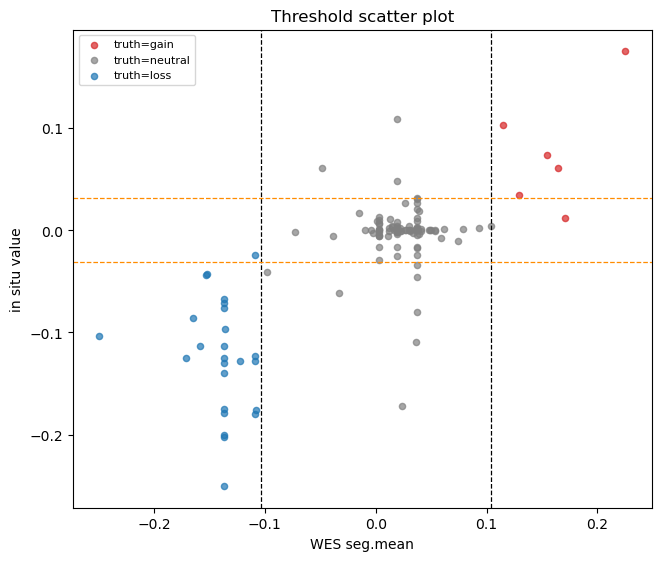

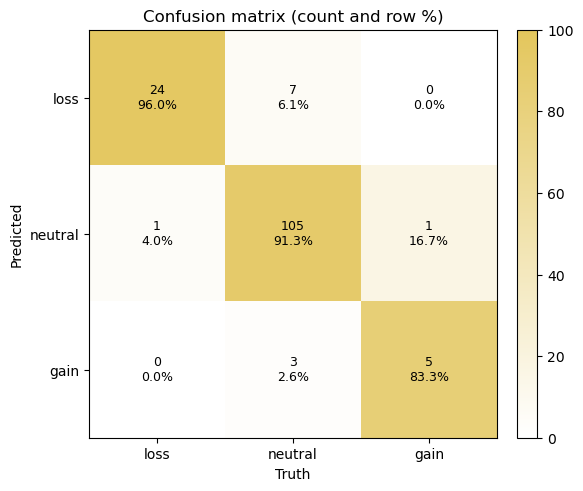

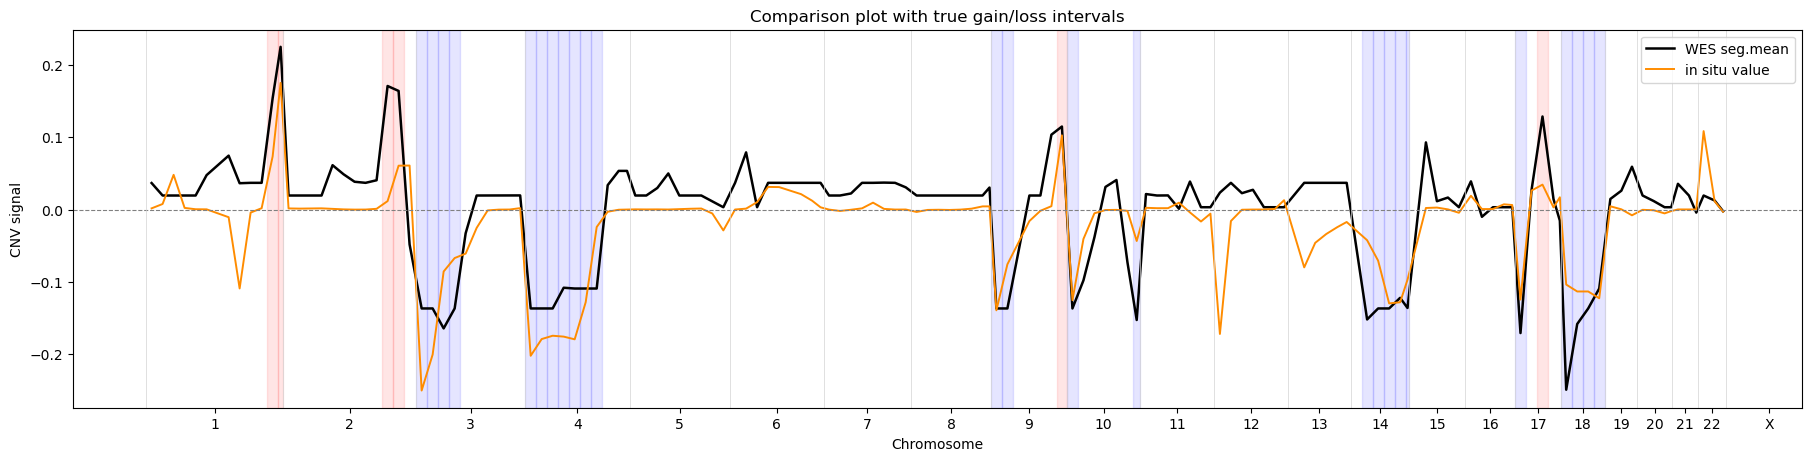

In [9]:
plot_threshold_scatter(metric_df, truth_labels, wes_thr, insitu_thr)
cm_counts_df, cm_pct_df = plot_confusion_matrix(truth_labels, pred_labels)
plot_truth_overlay(metric_df, chromosomes, offsets, chr_midpoints, genome_x)

save_dataframe(cm_counts_df.reset_index().rename(columns={'index': 'truth'}), 'confusion_matrix_counts', index=False)
save_dataframe(cm_pct_df.reset_index().rename(columns={'index': 'truth'}), 'confusion_matrix_row_pct', index=False)
